In [2]:
pip install wfdb

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Checking

Signal Shape: (650000, 2)
Sampling Frequency: 360
Number of Channels: 2
Annotation (sample indices of heartbeats and labels):
Sample: 18, Label: +
Sample: 77, Label: N
Sample: 370, Label: N
Sample: 662, Label: N
Sample: 946, Label: N


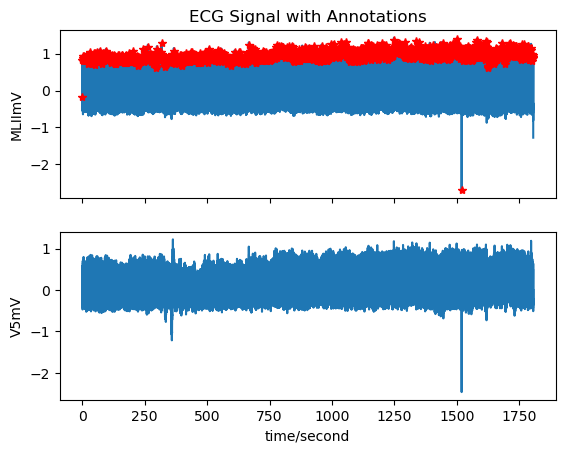

In [4]:
import wfdb

# Define the record to load from the MIT-BIH Arrhythmia Database
record_name = '100'  # Example record
pn_dir = 'mitdb'  # PhysioNet directory name for the MIT-BIH Arrhythmia Database

# Read the ECG signal and annotations from PhysioNet
record = wfdb.rdrecord(record_name, pn_dir=pn_dir)
annotation = wfdb.rdann(record_name, 'atr', pn_dir=pn_dir)

# Display basic information about the ECG signal
print(f"Signal Shape: {record.p_signal.shape}")
print(f"Sampling Frequency: {record.fs}")
print(f"Number of Channels: {record.n_sig}")

# Display the first 5 annotations (heartbeats and labels)
print("Annotation (sample indices of heartbeats and labels):")
for i in range(5):
    print(f"Sample: {annotation.sample[i]}, Label: {annotation.symbol[i]}")

# Plot the ECG signal and its annotations
wfdb.plot_wfdb(record=record, annotation=annotation, title='ECG Signal with Annotations')

Signal Shape: (650000, 2)
Sampling Frequency: 360
Number of Channels: 2
Annotation (sample indices of heartbeats and labels):
Sample: 36, Label: +
Sample: 73, Label: /
Sample: 316, Label: /
Sample: 615, Label: /
Sample: 901, Label: /


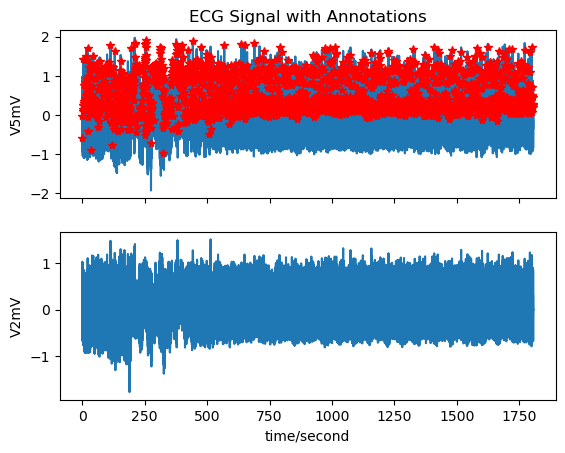

In [20]:
import wfdb

# Define the record to load from the MIT-BIH Arrhythmia Database
record_name = '104'  # Example record
pn_dir = 'mitdb'  # PhysioNet directory name for the MIT-BIH Arrhythmia Database

# Read the ECG signal and annotations from PhysioNet
record = wfdb.rdrecord(record_name, pn_dir=pn_dir)
annotation = wfdb.rdann(record_name, 'atr', pn_dir=pn_dir)

# Display basic information about the ECG signal
print(f"Signal Shape: {record.p_signal.shape}")
print(f"Sampling Frequency: {record.fs}")
print(f"Number of Channels: {record.n_sig}")

# Display the first 5 annotations (heartbeats and labels)
print("Annotation (sample indices of heartbeats and labels):")
for i in range(5):
    print(f"Sample: {annotation.sample[i]}, Label: {annotation.symbol[i]}")

# Plot the ECG signal and its annotations
wfdb.plot_wfdb(record=record, annotation=annotation, title='ECG Signal with Annotations')

# All MITBIH-AR ECG Signals

In [10]:
import wfdb
import numpy as np

# List of record names (used the full list of records from MIT-BIH)
record_names = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

# PhysioNet directory for MIT-BIH Arrhythmia Database
pn_dir = 'mitdb'

# Initialize an empty list to store the signals
signals_list = []

# Loop through each record, load the signals, and append to the list
for record_name in record_names:
    # Load the ECG signal (2 channels)
    record = wfdb.rdrecord(record_name, pn_dir=pn_dir)
    
    # Extract the signal as a 2D array (number_of_samples, 2)
    signal = record.p_signal
    
    # Append the transposed signal (to match shape (2, number_of_samples)) to the list
    signals_list.append(signal.T)  # Transpose so shape is (2, number_of_samples)

# Stack the signals into a single NumPy array
# Resulting shape will be (number_of_records, 2, number_of_samples)
# Note: All records must have the same number of samples
signals_array = np.stack(signals_list)

# Check the resulting array shape
print(f'Signals Array Shape: {signals_array.shape}')

Signals Array Shape: (48, 2, 650000)


In [11]:
import wfdb
import numpy as np

# List of record names (I used the full list of records from MIT-BIH)
record_names = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

# PhysioNet directory for MIT-BIH Arrhythmia Database
pn_dir = 'mitdb'

# Initialize an empty list to store the labels
labels_list = []

# Loop through each record, load the annotations, and append to the list
for record_name in record_names:
    # Load the annotations
    annotation = wfdb.rdann(record_name, 'atr', pn_dir=pn_dir)
    
    # Extract the labels (annotation symbols)
    labels = annotation.symbol
    
    # For simplicity, take the first label (you can adjust based on your specific needs)
    labels_list.append([labels[0]])  # Add as a 1D array with 1 element per record

# Convert the list to a NumPy array
# Resulting shape will be (number_of_records, 1)
labels_array = np.array(labels_list)

# Check the resulting array shape
print(f'Labels Array Shape: {labels_array.shape}')

Labels Array Shape: (48, 1)


In [16]:
import wfdb
import numpy as np
from collections import Counter

# List of record names (I used the full list of records from MIT-BIH)
record_names = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

# PhysioNet directory for MIT-BIH Arrhythmia Database
pn_dir = 'mitdb'

# Initialize an empty list to store the most frequent label for each record
labels_list = []

# Loop through each record, load the annotations, and find the most common label
for record_name in record_names:
    # Load the annotations
    annotation = wfdb.rdann(record_name, 'atr', pn_dir=pn_dir)
    
    # Extract the labels (annotation symbols)
    labels = annotation.symbol
    
    # Use Counter to find the most common label
    most_common_label = Counter(labels).most_common(1)[0][0]
    
    # Append the most common label to the list
    labels_list.append([most_common_label])  # Add as a 1D array with 1 element per record

# Convert the list to a NumPy array
# Resulting shape will be (number_of_records, 1)
labels_array = np.array(labels_list)

# Check the resulting array shape
print(f'Labels Array Shape: {labels_array.shape}')

# Print the most common labels for all records
print(f'Most common labels per record: {labels_array}')

Labels Array Shape: (48, 1)
Most common labels per record: [['N']
 ['N']
 ['/']
 ['N']
 ['/']
 ['N']
 ['N']
 ['/']
 ['N']
 ['L']
 ['L']
 ['N']
 ['N']
 ['N']
 ['N']
 ['N']
 ['N']
 ['R']
 ['N']
 ['N']
 ['N']
 ['N']
 ['R']
 ['N']
 ['N']
 ['N']
 ['N']
 ['N']
 ['L']
 ['N']
 ['N']
 ['N']
 ['R']
 ['N']
 ['L']
 ['N']
 ['/']
 ['N']
 ['N']
 ['N']
 ['N']
 ['N']
 ['N']
 ['N']
 ['R']
 ['A']
 ['N']
 ['N']]


In [18]:
import wfdb
import numpy as np
from collections import Counter

# List of record names (I used the full list of records from MIT-BIH)
record_names = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

# PhysioNet directory for MIT-BIH Arrhythmia Database
pn_dir = 'mitdb'

# Initialize an empty list to store the record numbers and the most frequent label for each record
labels_list = []

# Loop through each record, load the annotations, and find the most common label
for record_name in record_names:
    # Load the annotations
    annotation = wfdb.rdann(record_name, 'atr', pn_dir=pn_dir)
    
    # Extract the labels (annotation symbols)
    labels = annotation.symbol
    
    # Use Counter to find the most common label
    most_common_label = Counter(labels).most_common(1)[0][0]
    
    # Append the record number and the most common label to the list
    labels_list.append([int(record_name), most_common_label])  # Add record number and label

# Convert the list to a NumPy array
# Resulting shape will be (number_of_records, 2)
labels_array = np.array(labels_list)

# Check the resulting array shape
print(f'Labels Array Shape: {labels_array.shape}')

# Print the most common labels for all records
print(f'Most common labels per record:\n{labels_array}')

Labels Array Shape: (48, 2)
Most common labels per record:
[['100' 'N']
 ['101' 'N']
 ['102' '/']
 ['103' 'N']
 ['104' '/']
 ['105' 'N']
 ['106' 'N']
 ['107' '/']
 ['108' 'N']
 ['109' 'L']
 ['111' 'L']
 ['112' 'N']
 ['113' 'N']
 ['114' 'N']
 ['115' 'N']
 ['116' 'N']
 ['117' 'N']
 ['118' 'R']
 ['119' 'N']
 ['121' 'N']
 ['122' 'N']
 ['123' 'N']
 ['124' 'R']
 ['200' 'N']
 ['201' 'N']
 ['202' 'N']
 ['203' 'N']
 ['205' 'N']
 ['207' 'L']
 ['208' 'N']
 ['209' 'N']
 ['210' 'N']
 ['212' 'R']
 ['213' 'N']
 ['214' 'L']
 ['215' 'N']
 ['217' '/']
 ['219' 'N']
 ['220' 'N']
 ['221' 'N']
 ['222' 'N']
 ['223' 'N']
 ['228' 'N']
 ['230' 'N']
 ['231' 'R']
 ['232' 'A']
 ['233' 'N']
 ['234' 'N']]


In [19]:
import numpy as np

# Extract only the label column (second column)
labels_column = labels_array[:, 1]

# Find the unique labels and their counts
unique_labels, counts = np.unique(labels_column, return_counts=True)

# Print the unique labels and their corresponding counts
print(f"Unique labels: {unique_labels}")
print(f"Counts for each label: {counts}")

# Find the number of different labels
number_of_unique_labels = len(unique_labels)
print(f"Number of different labels: {number_of_unique_labels}")

Unique labels: ['/' 'A' 'L' 'N' 'R']
Counts for each label: [ 4  1  4 35  4]
Number of different labels: 5


In [12]:
import wfdb
import numpy as np

# List of record names (from MIT-BIH Arrhythmia Database)
record_names = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

# PhysioNet directory for MIT-BIH Arrhythmia Database
pn_dir = 'mitdb'

# Initialize an empty list to store the record numbers and data shapes
record_shapes = []

# Loop through each record, get the shape, and store it
for record_name in record_names:
    # Load the record
    record = wfdb.rdrecord(record_name, pn_dir=pn_dir)
    
    # Get the number of samples and channels (shape)
    num_samples, num_channels = record.p_signal.shape
    
    # Append the record number and number of samples to the list
    record_shapes.append([int(record_name), num_samples])

# Convert the list to a NumPy array
record_shapes_array = np.array(record_shapes)

# Print the resulting array
print("Record shapes array:\n", record_shapes_array)

# Check the array shape
print(f"Array Shape: {record_shapes_array.shape}")

Record shapes array:
 [[   100 650000]
 [   101 650000]
 [   102 650000]
 [   103 650000]
 [   104 650000]
 [   105 650000]
 [   106 650000]
 [   107 650000]
 [   108 650000]
 [   109 650000]
 [   111 650000]
 [   112 650000]
 [   113 650000]
 [   114 650000]
 [   115 650000]
 [   116 650000]
 [   117 650000]
 [   118 650000]
 [   119 650000]
 [   121 650000]
 [   122 650000]
 [   123 650000]
 [   124 650000]
 [   200 650000]
 [   201 650000]
 [   202 650000]
 [   203 650000]
 [   205 650000]
 [   207 650000]
 [   208 650000]
 [   209 650000]
 [   210 650000]
 [   212 650000]
 [   213 650000]
 [   214 650000]
 [   215 650000]
 [   217 650000]
 [   219 650000]
 [   220 650000]
 [   221 650000]
 [   222 650000]
 [   223 650000]
 [   228 650000]
 [   230 650000]
 [   231 650000]
 [   232 650000]
 [   233 650000]
 [   234 650000]]
Array Shape: (48, 2)


In [ ]:
### Check all records to get info on the availability of MLII

In [21]:
import wfdb

# PhysioNet directory for MIT-BIH Arrhythmia Database
pn_dir = 'mitdb'

# List of record names
record_names = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

for record_name in record_names:
    # Read the header file to check available leads
    record = wfdb.rdheader(record_name, pn_dir=pn_dir)
    
    # Check if MLII is present in the signal names
    if 'MLII' in record.sig_name:
        ml_ii_column = record.sig_name.index('MLII')  # Get the column index of MLII
        print(f"Record {record_name} has MLII in column {ml_ii_column}.")
    else:
        print(f"Record {record_name} does not have MLII.")


Record 100 has MLII in column 0.
Record 101 has MLII in column 0.
Record 102 does not have MLII.
Record 103 has MLII in column 0.
Record 104 does not have MLII.
Record 105 has MLII in column 0.
Record 106 has MLII in column 0.
Record 107 has MLII in column 0.
Record 108 has MLII in column 0.
Record 109 has MLII in column 0.
Record 111 has MLII in column 0.
Record 112 has MLII in column 0.
Record 113 has MLII in column 0.
Record 114 has MLII in column 1.
Record 115 has MLII in column 0.
Record 116 has MLII in column 0.
Record 117 has MLII in column 0.
Record 118 has MLII in column 0.
Record 119 has MLII in column 0.
Record 121 has MLII in column 0.
Record 122 has MLII in column 0.
Record 123 has MLII in column 0.
Record 124 has MLII in column 0.
Record 200 has MLII in column 0.
Record 201 has MLII in column 0.
Record 202 has MLII in column 0.
Record 203 has MLII in column 0.
Record 205 has MLII in column 0.
Record 207 has MLII in column 0.
Record 208 has MLII in column 0.
Record 209 has

In [ ]:
### Find which channel has MLII

In [22]:
import wfdb
import numpy as np

# List of valid labels in the MIT-BIH Arrhythmia dataset
valid_labels = ['N', 'L', 'R', 'V', '/', 'A', 'f', 'F', '!', 'j', 'x', 'a', 'E', 'J', 'e', 'Q']

# Number of samples to take before and after the annotation point
SAMPLES_BEFORE = 71
SAMPLES_AFTER = 144
SEGMENT_LENGTH = SAMPLES_BEFORE + SAMPLES_AFTER + 1  # Total length of each segment

# Initialize lists to store the segmented data and corresponding labels
segments = []
segment_labels = []

# List of record names (example set)
record_names = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

# PhysioNet directory for MIT-BIH Arrhythmia Database
pn_dir = 'mitdb'

# Loop through each record
for record_name in record_names:
    # Read the header file to check available leads
    record = wfdb.rdheader(record_name, pn_dir=pn_dir)
    
    # Check if MLII is present in the signal names
    if 'MLII' in record.sig_name:
        ml_ii_column = record.sig_name.index('MLII')  # Get the column index of MLII
        print(f"Processing Record {record_name} (MLII in column {ml_ii_column})...")
        
        # Load the record (MLII lead only)
        record = wfdb.rdrecord(record_name, pn_dir=pn_dir, channels=[ml_ii_column])
        
        # Load the annotations
        annotation = wfdb.rdann(record_name, 'atr', pn_dir=pn_dir)
        
        # Get the signal data (MLII channel)
        signal = record.p_signal[:, 0]
        
        # Loop through each annotation
        for i in range(len(annotation.sample)):
            sample_point = annotation.sample[i]
            label = annotation.symbol[i]
            
            # Only process if the label is one of the valid labels
            if label in valid_labels:
                # Ensure that we can take 71 samples before and 144 after the sample point
                if sample_point >= SAMPLES_BEFORE and sample_point + SAMPLES_AFTER < len(signal):
                    # Extract the segment of 216 samples
                    segment = signal[sample_point - SAMPLES_BEFORE : sample_point + SAMPLES_AFTER + 1]
                    
                    # Append the segment and its corresponding label
                    segments.append(segment)
                    segment_labels.append(label)
    else:
        print(f"Record {record_name} does not have MLII. Skipping.")

# Convert the lists to NumPy arrays
segments_array = np.array(segments)
labels_array = np.array(segment_labels).reshape(-1, 1)

# Print the shapes of the resulting arrays
print(f'Segments Array Shape: {segments_array.shape}')  # (total_number_of_segments, 216)
print(f'Labels Array Shape: {labels_array.shape}')      # (total_number_of_segments, 1)


Processing Record 100 (MLII in column 0)...
Processing Record 101 (MLII in column 0)...
Record 102 does not have MLII. Skipping.
Processing Record 103 (MLII in column 0)...
Record 104 does not have MLII. Skipping.
Processing Record 105 (MLII in column 0)...
Processing Record 106 (MLII in column 0)...
Processing Record 107 (MLII in column 0)...
Processing Record 108 (MLII in column 0)...
Processing Record 109 (MLII in column 0)...
Processing Record 111 (MLII in column 0)...
Processing Record 112 (MLII in column 0)...
Processing Record 113 (MLII in column 0)...
Processing Record 114 (MLII in column 1)...
Processing Record 115 (MLII in column 0)...
Processing Record 116 (MLII in column 0)...
Processing Record 117 (MLII in column 0)...
Processing Record 118 (MLII in column 0)...
Processing Record 119 (MLII in column 0)...
Processing Record 121 (MLII in column 0)...
Processing Record 122 (MLII in column 0)...
Processing Record 123 (MLII in column 0)...
Processing Record 124 (MLII in column 

In [28]:
# Extract the unique labels and their counts
unique_labels, counts = np.unique(labels_array, return_counts=True)

# Print the unique labels and their corresponding counts
print(f"Unique labels: {unique_labels}")
print(f"Counts for each label: {counts}")

Unique labels: ['!' '/' 'A' 'E' 'F' 'J' 'L' 'N' 'Q' 'R' 'V' 'a' 'e' 'f' 'j' 'x']
Counts for each label: [  472  3620  2546   106   802    83  8072 74766    15  7255  7123   150
    16   260   229   193]


In [25]:
import numpy as np

# Create a dictionary mapping each label to a numeric value
label_mapping = {
    'N': 0,  # Normal beat
    'L': 1,  # Left bundle branch block beat
    'R': 2,  # Right bundle branch block beat
    'V': 3,  # Premature ventricular contraction
    '/': 4,  # Paced beat
    'A': 5,  # Atrial premature beat
    'f': 6,  # Fusion of paced and normal beat
    'F': 7,  # Fusion of ventricular and normal beat
    '!': 8,  # Ventricular flutter wave
    'j': 9,  # Nodal (junctional) premature beat
    'x': 10,  # Non-conducted beat
    'a': 11,  # Aberrated atrial premature beat
    'E': 12,  # Ventricular escape beat
    'J': 13,  # Nodal (junctional) escape beat
    'e': 14,  # Atrial escape beat
    'Q': 15   # Unclassifiable beat
}

# Convert the labels to numeric using the mapping
numeric_labels = np.array([label_mapping[label[0]] for label in labels_array])

# Reshape the result to match the original array shape (number_of_segments, 1)
numeric_labels_array = numeric_labels.reshape(-1, 1)

# Print the resulting numeric labels array
print("Numeric Labels Array:")
print(numeric_labels_array)

Numeric Labels Array:
[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]


In [27]:
import h5py
import numpy as np

# Save the arrays in an HDF5 file
with h5py.File('MITBIHAR.h5', 'w') as h5f:
    h5f.create_dataset('ECG_Signals', data=segments_array)
    h5f.create_dataset('ECG_Labels', data=numeric_labels_array)

print("Arrays saved successfully in MITBIHAR.h5")

Arrays saved successfully in MITBIHAR.h5


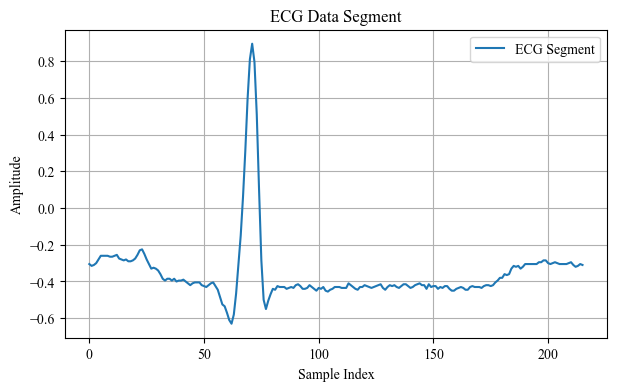

In [32]:
plot_index = 100

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Update matplotlib settings to use 'Times New Roman' font
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

# Select a segment to plot (for example, the first segment)
segment_to_plot = segments_array[plot_index]

# Plot the segment
plt.figure(figsize=(7, 4))
plt.plot(segment_to_plot, label="ECG Segment")
plt.title("ECG Data Segment")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# MITBIHAR: Filtering (with baseline correction) and Segmentation

In [67]:
# List of record names
record_names = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

In [93]:
import wfdb
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch
import pywt

# List of record names
record_names = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

# Define High-pass, Low-pass, and Notch filters
def butter_highpass(cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def butter_lowpass(cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def notch_filter(freq, fs, quality_factor=30):
    nyquist = 0.5 * fs
    w0 = freq / nyquist
    b, a = iirnotch(w0, quality_factor)
    return b, a

def apply_filter(data, b, a):
    return filtfilt(b, a, data)

# Perform high-pass, low-pass, and notch filtering
def filter_ecg_signal(ecg_signal, fs):
    # Apply High-pass filter to remove baseline wander
    b_high, a_high = butter_highpass(0.5, fs)
    ecg_filtered = apply_filter(ecg_signal, b_high, a_high)
    
    # Apply Low-pass filter to remove high-frequency noise
    b_low, a_low = butter_lowpass(40, fs)
    ecg_filtered = apply_filter(ecg_filtered, b_low, a_low)
    
    # Apply Notch filter to remove powerline interference (50Hz)
    b_notch, a_notch = notch_filter(50, fs)
    ecg_filtered = apply_filter(ecg_filtered, b_notch, a_notch)
    
    return ecg_filtered

# Baseline correction
def baseline_correction(ecg_signal, wavelet='db6', level=8):
    max_level = pywt.dwt_max_level(len(ecg_signal), pywt.Wavelet(wavelet).dec_len)
    level = min(level, max_level)
    coeffs = pywt.wavedec(ecg_signal, wavelet, level=level)
    coeffs[0] = np.zeros_like(coeffs[0])  # Remove low-frequency components
    corrected_signal = pywt.waverec(coeffs, wavelet)
    return corrected_signal[:len(ecg_signal)]  # Ensure same length

# Function to normalize ECG signals
def normalize_signals(data):
    normalized_data = np.zeros_like(data)
    for i in range(data.shape[0]):
        patient_data = data[i]
        min_val = patient_data.min()
        max_val = patient_data.max()
        max_abs_val = max(abs(min_val), abs(max_val))
        if max_abs_val != 0:  # Avoid division by zero
            normalized_data[i] = patient_data / max_abs_val
        else:
            normalized_data[i] = patient_data  # No normalization if max_abs_val is zero
    return normalized_data

# List of valid labels in the MIT-BIH Arrhythmia dataset
valid_labels = ['N', 'L', 'R', 'V', '/', 'A', 'f', 'F', '!', 'j', 'x', 'a', 'E', 'J', 'e', 'Q']

# Number of samples to take before and after the annotation point
SAMPLES_BEFORE = 71
SAMPLES_AFTER = 144
SEGMENT_LENGTH = SAMPLES_BEFORE + SAMPLES_AFTER + 1  # Total length of each segment

# Initialize lists to store the segmented data and corresponding labels
segments = []
segment_labels = []

# List of record names
#record_names = ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']

# PhysioNet directory for MIT-BIH Arrhythmia Database
pn_dir = 'mitdb'

# Sampling frequency
fs = 360  # Most MIT-BIH ECG signals are sampled at 360 Hz

# Loop through each record
for record_name in record_names:
    # Read the header file to check available leads
    record = wfdb.rdheader(record_name, pn_dir=pn_dir)
    
    # Check if MLII is present in the signal names
    if 'MLII' in record.sig_name:
        ml_ii_column = record.sig_name.index('MLII')  # Get the column index of MLII
        print(f"Processing Record {record_name} (MLII in column {ml_ii_column})...")
        
        # Load the record (MLII lead only)
        record = wfdb.rdrecord(record_name, pn_dir=pn_dir, channels=[ml_ii_column])
        
        # Load the annotations
        annotation = wfdb.rdann(record_name, 'atr', pn_dir=pn_dir)
        
        # Get the signal data (MLII channel)
        signal = record.p_signal[:, 0]
        
        # Apply filtering
        filtered_signal = filter_ecg_signal(signal, fs)
        
        # Apply baseline correction
        corrected_signal = filtered_signal
        #corrected_signal = baseline_correction(filtered_signal) # Uncomment to apply baseline correction
        
        # Normalize the signal
        normalized_signal = corrected_signal
        #normalized_signal = normalize_signals(corrected_signal.reshape(1, -1))[0] # Uncomment to apply normalization
        
        # Loop through each annotation
        for i in range(len(annotation.sample)):
            sample_point = annotation.sample[i]
            label = annotation.symbol[i]
            
            # Only process if the label is one of the valid labels
            if label in valid_labels:
                # Ensure that we can take 71 samples before and 144 after the sample point
                if sample_point >= SAMPLES_BEFORE and sample_point + SAMPLES_AFTER < len(normalized_signal):
                    # Extract the segment of 216 samples
                    segment = normalized_signal[sample_point - SAMPLES_BEFORE : sample_point + SAMPLES_AFTER + 1]
                    
                    # Append the segment and its corresponding label
                    segments.append(segment)
                    segment_labels.append(label)
    else:
        print(f"Record {record_name} does not have MLII. Skipping.")

# Convert the lists to NumPy arrays
segments_array = np.array(segments)
labels_array = np.array(segment_labels).reshape(-1, 1)

# Print the shapes of the resulting arrays
print(f'Segments Array Shape: {segments_array.shape}')  # (total_number_of_segments, 216)
print(f'Labels Array Shape: {labels_array.shape}')      # (total_number_of_segments, 1)

Processing Record 100 (MLII in column 0)...
Processing Record 101 (MLII in column 0)...
Record 102 does not have MLII. Skipping.
Processing Record 103 (MLII in column 0)...
Record 104 does not have MLII. Skipping.
Processing Record 105 (MLII in column 0)...
Processing Record 106 (MLII in column 0)...
Processing Record 107 (MLII in column 0)...
Processing Record 108 (MLII in column 0)...
Processing Record 109 (MLII in column 0)...
Processing Record 111 (MLII in column 0)...
Processing Record 112 (MLII in column 0)...
Processing Record 113 (MLII in column 0)...
Processing Record 114 (MLII in column 1)...
Processing Record 115 (MLII in column 0)...
Processing Record 116 (MLII in column 0)...
Processing Record 117 (MLII in column 0)...
Processing Record 118 (MLII in column 0)...
Processing Record 119 (MLII in column 0)...
Processing Record 121 (MLII in column 0)...
Processing Record 122 (MLII in column 0)...
Processing Record 123 (MLII in column 0)...
Processing Record 124 (MLII in column 

In [94]:
# Extract the unique labels and their counts
unique_labels, counts = np.unique(labels_array, return_counts=True)

# Print the unique labels and their corresponding counts
print(f"Unique labels: {unique_labels}")
print(f"Counts for each label: {counts}")

Unique labels: ['!' '/' 'A' 'E' 'F' 'J' 'L' 'N' 'Q' 'R' 'V' 'a' 'e' 'f' 'j' 'x']
Counts for each label: [  472  3620  2546   106   802    83  8072 74766    15  7255  7123   150
    16   260   229   193]


In [95]:
import numpy as np

# Create a dictionary mapping each label to a numeric value
label_mapping = {
    'N': 0,  # Normal beat
    'L': 1,  # Left bundle branch block beat
    'R': 2,  # Right bundle branch block beat
    'V': 3,  # Premature ventricular contraction
    '/': 4,  # Paced beat
    'A': 5,  # Atrial premature beat
    'f': 6,  # Fusion of paced and normal beat
    'F': 7,  # Fusion of ventricular and normal beat
    '!': 8,  # Ventricular flutter wave
    'j': 9,  # Nodal (junctional) premature beat
    'x': 10,  # Non-conducted beat
    'a': 11,  # Aberrated atrial premature beat
    'E': 12,  # Ventricular escape beat
    'J': 13,  # Nodal (junctional) escape beat
    'e': 14,  # Atrial escape beat
    'Q': 15   # Unclassifiable beat
}

# Convert the labels to numeric using the mapping
numeric_labels = np.array([label_mapping[label[0]] for label in labels_array])

# Reshape the result to match the original array shape (number_of_segments, 1)
numeric_labels_array = numeric_labels.reshape(-1, 1)

# Print the resulting numeric labels array
print("Numeric Labels Array:")
print(numeric_labels_array)

Numeric Labels Array:
[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]


In [96]:
# Extract the unique labels and their counts
unique_labels, counts = np.unique(numeric_labels_array, return_counts=True)

# Print the unique labels and their corresponding counts
print(f"Unique labels: {unique_labels}")
print(f"Counts for each label: {counts}")

Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Counts for each label: [74766  8072  7255  7123  3620  2546   260   802   472   229   193   150
   106    83    16    15]


In [97]:
import h5py
import numpy as np

# Save the arrays in an HDF5 file
with h5py.File('2.MITBIHAR_Filtered_Segmented_1CH_360Hz.h5', 'w') as h5f:
    h5f.create_dataset('ECG_Signals', data=segments_array)
    h5f.create_dataset('ECG_Labels', data=numeric_labels_array)

print("Arrays saved successfully in 2.MITBIHAR_Filtered_Segmented_1CH_360Hz.h5")

Arrays saved successfully in 2.MITBIHAR_Filtered_Segmented_1CH_360Hz.h5


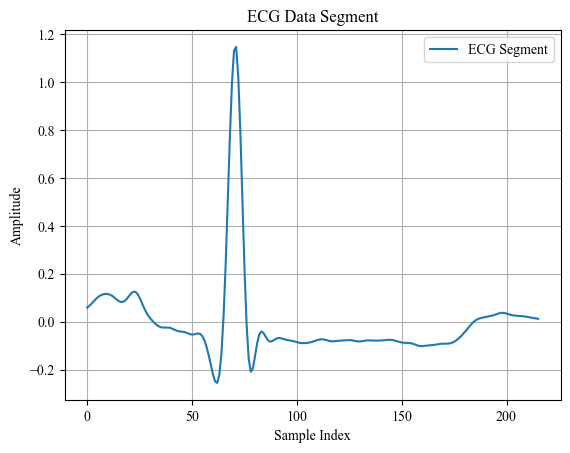

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Update matplotlib settings to use 'Times New Roman' font
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

# Select a segment to plot (for example, the first segment)
segment_to_plot = segments_array[plot_index]

# Plot the segment
#plt.figure(figsize=(7, 4))
plt.plot(segment_to_plot, label="ECG Segment")
plt.title("ECG Data Segment")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
# Save the figure as a PDF
plt.savefig('2.MITBIHAR_MLII_Filtered_Segmented_1CH.pdf', format='pdf', dpi=1200)  # Save with specified dpi
plt.show()

In [98]:
import numpy as np

# Assuming `data` is your original dataset of shape (_, 2, 216)
def downsample(data, target_size):
    factor = data.shape[-1] // target_size  # Calculate downsampling factor
    downsampled_data = data[:, ::factor]  # Slice every 'factor' element
    return downsampled_data

# Your original data
data = segments_array

# Downsample to shape (_, 2, 77)
downsampled_data = downsample(data, 77)

print(downsampled_data.shape)  # Should print (_, 2, 77)

(105708, 108)


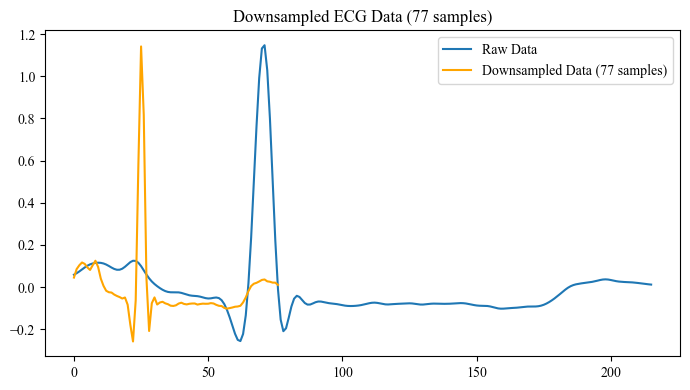

In [99]:
from scipy.signal import resample

# Downsample using precise resampling to get exactly 77 samples
def precise_downsample(data, target_size):
    # Resample along the last axis to match the target size
    downsampled_data = resample(data, target_size, axis=-1)
    return downsampled_data

# Downsample to shape (94805, 2, 77)
precise_downsampled_data = precise_downsample(data, 77)

# Extract the same sample for visualization
sample_index = 100
lead_index = 0
raw_data = data[sample_index, :]
precise_downsampled = precise_downsampled_data[sample_index, :]

# Plot raw and precisely downsampled data
plt.figure(figsize=(7, 4))

# Plot raw data
#plt.subplot(2, 1, 1)
plt.plot(raw_data, label="Raw Data")
plt.title("Raw ECG Data (216 samples)")
plt.legend()

# Plot precisely downsampled data
#plt.subplot(2, 1, 2)
plt.plot(precise_downsampled, label="Downsampled Data (77 samples)", color='orange')
plt.title("Downsampled ECG Data (77 samples)")
plt.legend()

plt.savefig('2.MITBIHAR_Filtered_Segmented_1CH_128Hz.pdf', format='pdf', dpi=1200)  # Save with specified dpi

plt.tight_layout()
plt.show()

In [100]:
precise_downsampled_data.shape

(105708, 77)

In [101]:
import h5py
import numpy as np

# Save the arrays in an HDF5 file
with h5py.File('2.MITBIHAR_Filtered_Segmented_1CH_128Hz.h5', 'w') as h5f:
    h5f.create_dataset('ECG_Signals', data=precise_downsampled_data)
    h5f.create_dataset('ECG_Labels', data=numeric_labels_array)

print("Arrays saved successfully in 2.MITBIHAR_Filtered_Segmented_1CH_128Hz.h5")

Arrays saved successfully in 2.MITBIHAR_Filtered_Segmented_1CH_128Hz.h5
